# Energy Systems Group Assignment 2026

Input data (`students/data`) comes from a 49-node European PyPSA network (2019 weather year):
the **windiest** node (DK1) is *North*, the **sunniest** node (ES0) is *South*, sampled as four
representative weeks (winter/spring/summer/autumn) at 3-hourly resolution (224 snapshots).
Costs are aligned with `costs_2050`. Solved with HiGHS.

Build a **two-node capacity expansion model** from scratch and analyse the value of transmission.
See the slides for the full problem description and graded questions.

The input data in `data/` must be read as-is — do not regenerate it.

For **every quantitative subtask** report a **quantity**, a **plot**, and a short **interpretation**.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import linopy as lp
import xarray as xr
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "students" / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate students/data from the current working directory")

In [7]:
REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR  = REPO_ROOT / "students" / "data"
DT = 3.0  # hours per snapshot

tech_data = pd.read_csv(DATA_DIR / "tech_data.csv",  index_col=0)
load      = pd.read_csv(DATA_DIR / "load.csv",        index_col=0, parse_dates=True)
cf        = pd.read_csv(DATA_DIR / "capacity_factors.csv", index_col=0, parse_dates=True)

nodes      = ["north", "south"]
node_index = pd.Index(nodes, name="node")
time_index = pd.Index(load.index, name="time")
T_WINDOW   = DT * len(time_index)   # 672 h
YEAR_FRACTION = T_WINDOW / 8760

wind_cf = xr.DataArray(
    pd.DataFrame({"north": cf["wind_north"], "south": cf["wind_south"]}).to_numpy(),
    coords={"time": time_index, "node": node_index}, dims=("time","node"), name="wind_cf")
solar_cf = xr.DataArray(
    pd.DataFrame({"north": cf["solar_north"], "south": cf["solar_south"]}).to_numpy(),
    coords={"time": time_index, "node": node_index}, dims=("time","node"), name="solar_cf")
demand_da = xr.DataArray(
    load[nodes].to_numpy(),
    coords={"time": time_index, "node": node_index}, dims=("time","node"), name="demand")

tech_data

,kind,c_var_other,overnight_cost,FOM,lifetime,efficiency
component,,,,,,
Wind,power,1.623,1286467.0,15148.0,30.0,NaN
Solar,power,0.000,367867.0,9304.0,40.0,NaN
H2_electrolyser,charge_power,0.000,1257335.0,50293.0,25.0,0.6994
H2_fuel_cell,discharge_power,0.000,1068642.0,53432.0,10.0,0.5000
H2_store,energy,0.000,1604.0,0.0,100.0,NaN
Battery_inverter,power,0.000,80223.0,722.0,10.0,0.9600
Battery_store,energy,0.000,100279.0,0.0,30.0,NaN
Line,power,0.000,1544274.0,23164.0,40.0,NaN


### Input data — capacity factors and demand (4 seasonal weeks, 3-hourly)

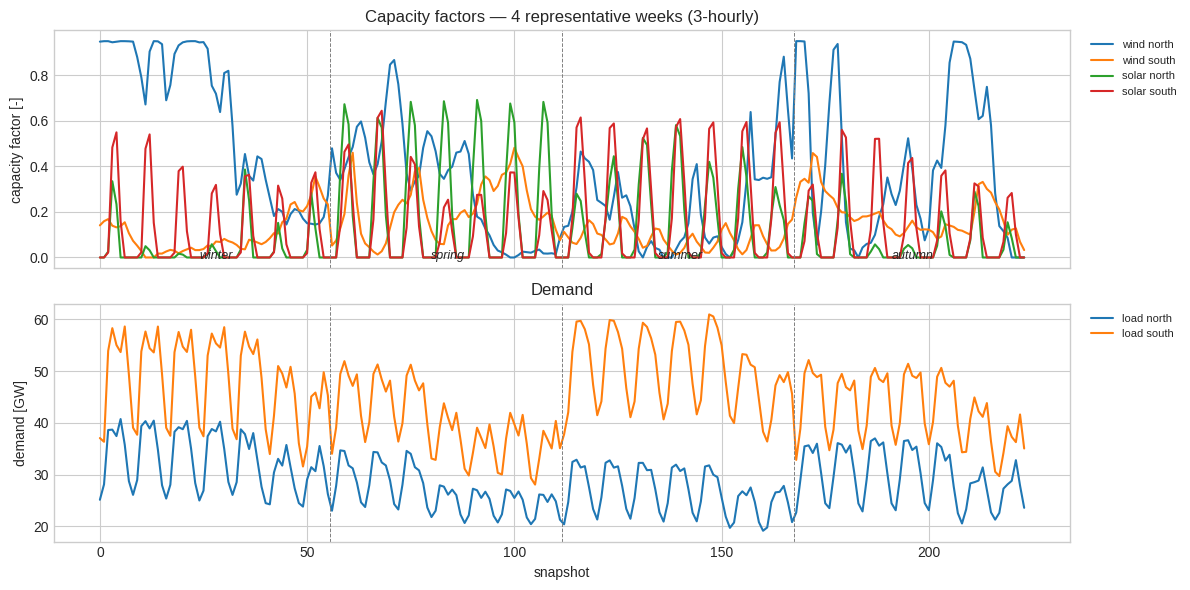

In [8]:
seasons = load["season"].values
bounds  = np.where(seasons[:-1] != seasons[1:])[0] + 0.5
x = np.arange(len(load))

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(x, cf["wind_north"],  label="wind north")
ax[0].plot(x, cf["wind_south"],  label="wind south")
ax[0].plot(x, cf["solar_north"], label="solar north")
ax[0].plot(x, cf["solar_south"], label="solar south")
ax[0].set_ylabel("capacity factor [-]")
ax[0].set_title("Capacity factors — 4 representative weeks (3-hourly)")
ax[0].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

ax[1].plot(x, load["north"]/1e3, label="load north")
ax[1].plot(x, load["south"]/1e3, label="load south")
ax[1].set_ylabel("demand [GW]")
ax[1].set_xlabel("snapshot")
ax[1].set_title("Demand")
ax[1].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

for b in bounds:
    for a_ in ax: a_.axvline(b, color="grey", ls="--", lw=0.7)
for i, lab in enumerate(["winter", "spring", "summer", "autumn"]):
    ax[0].text(28 + 56*i, 0.04, lab, ha="center", fontsize=9, style="italic",
               transform=ax[0].get_xaxis_transform())

plt.tight_layout()
plt.savefig("fig_inputdata.png", dpi=120, bbox_inches="tight")
plt.show()

## Task 1 — Build the model and present the primal solution (3 pts)

Build a two-node capacity expansion model from scratch.
Solve for **Scenario B** (no line, `line_cap` forced to 0) and **Scenario A** (line as a free
decision variable). All investment costs are annualised with the annuity factor at `r = 7%` and
pro-rated to the modelled window via `YEAR_FRACTION`.

### Task 1a — Annuity factor and annualised investment costs (0.5 pt)

Compute the **annuity factor $a(r,L)$** and the **annualised investment costs** for all technologies ($r = 7\%$):

$$a(r,L) = \frac{r(1+r)^L}{(1+r)^L - 1}, \qquad c_\mathrm{inv} = \mathrm{overnight} \cdot a(r,L) + \mathrm{FOM}$$

**Output:** table.

In [9]:
# TODO 1a — compute annuity factor and annualised investment costs (r = 0.07)


### Task 1b — Dispatch in the no-line scenario (0.5 pt)

In the **no-line case**, what does the dispatch of **solar and wind** look like in each node?

**Output:** dispatch plot.

In [10]:
# TODO 1b — extract annualised cost and efficiency parameters from tech_data,
#            then implement def solve(allow_line: bool) and run mB = solve(False)


In [11]:
# TODO 1b (continued) — plot the dispatch for Scenario B


### Task 1c — Compare the two scenarios (1 pt)

**Compare the two scenarios.** How do the investments into **generation, storage, and transmission** change?

**Output:** show the investment costs in a table and plot the capacities.

In [12]:
# TODO 1c — solve Scenario A: mA = solve(True)
#            print TOTEX for A and B, and the line capacity built


In [13]:
# TODO 1c (continued) — investment cost decomposition table and stacked-bar chart


In [14]:
# TODO 1c (continued) — generation and storage capacity comparison plots


### Task 1d — Curtailment (0.5 pt)

How does **curtailment** by technology and region change from the **no-line case** to the **transmission case** and why?

**Output:** quantify and explain.

In [15]:
# TODO 1d — compute and plot vRES curtailment by technology for both scenarios


### Task 1e — Residual load curves (0.5 pt)

How do the **residual load curves** change across the two scenarios?

**Output:** plot the residual load curves and explain the differences.

In [16]:
# TODO 1e — compute and plot aggregate residual-load duration curves for both scenarios


## Task 2 — Interpret the dual solution: shadow prices (2 pts)

No additional plots required unless stated. The **nodal price** is the balance-constraint dual
divided by `DT` (EUR/MWh). Investment pro-rating ensures these are realistic energy prices.

### Task 2a — Shadow prices of the nodal energy balances (0.5 pt)

For each scenario, extract the **shadow variable of the nodal energy balances** and weight it by the nodal demand in the north and south, respectively. What do they represent? Why are they different in the two regions? When do you observe the highest values and why?

In [17]:
# TODO 2a — extract nodal balance duals, compute demand-weighted prices,
#            and plot nodal price duration curves for A and B


### Task 2b — Consumer benefit from transmission (0.5 pt)

In the transmission scenario, **consumers of which region** benefit more from the transmission line: the north, the south, or both equally? Briefly explain.

In [18]:
# TODO 2b — compute demand-weighted average nodal prices for both scenarios
#            and plot the comparison


### Task 2c — Shadow price of the line-capacity constraint (0.5 pt)

Extract the **shadow price of the line-capacity constraint** in the transmission scenario. What does it represent? In the scenario where the transmission capacity is zero, you can also extract the dual variable. Comparing the two, what does it say about the **value of interconnection**?

In [19]:
# TODO 2c — extract the shadow price of the line-capacity constraint
#            for both scenarios and plot the comparison


### Task 2d — Advantages and disadvantages of heavy interconnection (0.5 pt)

Which advantages and disadvantages of heavy reliance on **cross-regional interconnection** does this stylised model *not* capture? No calculation needed.